# MiMo-V2.6-Flash-RL on CMP 170HX (SM80) — vLLM, pipeline parallel

| Metric | Value |
|---|---|
| Verdict | **SERVES — correct output, 3 cards, PP3 + native MTP k=2** (measured 2026-09-23/24) |
| Decode, single stream, greedy (P1 median, 5 workloads) | **116.9 tok/s** PP3+MTP2 · 75.0 PP3 · 68.3 PP4 |
| Decode, sampled T=1.0 (P2 median, warm) | **90.7 tok/s** PP3+MTP2 · 74.4 PP3 · 67.7 PP4 |
| TTFT (short prompts, median) | 0.10 s PP3 · 0.11 s PP4 |
| Prefill (uncached, PP3 + DFlash k=7 server) | ~2.3k tok/s at 2.7k tokens → ~3.4k tok/s at 21.5k tokens |
| Functional gate | PP3 and PP3+MTP 4/4 correct + identical greedy · PP4 4/4 correct, 3/4 identical |
| DFlash k=7 (shipped drafter) | **162.1 tok/s greedy** (240 on counting, 184 math) · 77.5 sampled — best for greedy/code/math |
| Aggregate throughput, 32 streams | **495 tok/s** PP3+MTP2 · 447 PP3 · 418 PP4 · 78 TP4 |
| MTP acceptance | mean accepted length ~2.1 at k=2/3; per-position ~0.66 / 0.30 / 0.08 |
| KV cache (PP3, 16k context) | 73,202 tokens (4.5x concurrency at 16k) |
| Runtime | club fork image (PixelML/sm80vllm) + upstream vLLM MiMo backports (mimo_v2.py, mimo_v2_mtp.py) |

![single-stream decode by configuration and aggregate throughput vs concurrency](../assets/charts/2026-09-22-mimo-v2.6-flash-4card-pp4-vllm.png)

**PP3 on three cards beats PP4 on four** — one fewer pipeline hop, and it leaves the
x1-riser card out entirely. Getting correct output at all took six separate SM80
problems (section 3) and three fixes (section 4); each is tied to a receipt.

```bash
docker pull ghcr.io/pixelml/club-170hx:vllm-glm53-sm80-pp-20260905
```

In [1]:
# --- Status cell ---
EXPERIMENT = "2026-09-22-mimo-v2.6-flash-4card-pp4-vllm"
RESULTS_DIR = "../results/" + EXPERIMENT
RECEIPTS = RESULTS_DIR + "/receipts"
LIVE = False
ENDPOINT_ENV_VAR = "MIMO_ENDPOINT_URL"  # read only when LIVE = True; never hardcode an endpoint

print(f"experiment : {EXPERIMENT}")
print(f"LIVE       : {LIVE}")
print("status     : serving. PP3 + MTP k=2 recommended; PP3, PP4, MTP k=3, DFlash k=4/7 measured. Receipts: receipts/")

experiment : 2026-09-22-mimo-v2.6-flash-4card-pp4-vllm
LIVE       : False
status     : serving. PP3 + MTP k=2 recommended; PP3, PP4, MTP k=3, DFlash k=4/7 measured. Receipts: receipts/


In [2]:
# --- Helpers: receipt loader and table renderer ---
import json, os, statistics
from IPython.display import display, Markdown


def receipt(*parts):
    path = os.path.join(RECEIPTS, *parts)
    with open(path) as fh:
        return json.load(fh)


def render_table(headers, rows):
    lines = ["| " + " | ".join(str(h) for h in headers) + " |",
             "|" + "|".join(["---"] * len(headers)) + "|"]
    for row in rows:
        lines.append("| " + " | ".join(str(c) for c in row) + " |")
    display(Markdown(chr(10).join(lines)))


assert not LIVE, "commit this notebook with LIVE = False"
print("receipts:", sorted(os.listdir(RECEIPTS)) if os.path.isdir(RECEIPTS) else "missing")

receipts: ['acceptance.json', 'bench', 'conc', 'fork_resolution.json', 'hardware.json', 'prefill.json', 'runtime_attempts.json']


## 1. TL;DR

- **It runs.** MiMo-V2.6-Flash-RL (309B MoE, mxfp4 routed experts, fp8 block attention,
  attention sinks, DiffKV heads) serves correct, stable output on three CMP 170HX cards
  at 75 tok/s single-stream decode, **117 tok/s with the shipped MTP head (k=2)** and
  **162 tok/s greedy with the shipped DFlash drafter (k=7)**.
- **Why it was hard:** every production kernel this model ships for is SM90+, the
  checkpoint is pre-sharded for a TP4 layout this PCIe fabric cannot run well, the weights
  only just fit, and the crash that blocked every early boot was a driver bug that looked
  like a kernel bug (section 3).
- **Three fixes, all measured:** (1) a memory-unlock driver bug that crashed every big
  boot, (2) the upstream vLLM MiMo QKV-sharding fix backported onto the fork image,
  (3) a benchmark-tool bug that inflated decode rates on reasoning prompts.

In [3]:
pins = {
    "model": "MiMo-V2.6-Flash-RL",
    "checkpoint": "XiaomiMiMo/MiMo-V2.6-Flash-RL",
    "checkpoint_revision": "5711b268169967567844e1e560e8a3966da959b1",
    "checkpoint_bytes": 172932505264,  # 65 shards, verified via tools/verify_checkpoint.py
    "quantization": "FP8 e4m3 block 128x128 dense/attention; routed experts MXFP4 (e8m0 block-32 scales)",
    "image": "ghcr.io/pixelml/club-170hx:vllm-glm53-sm80-pp-20260905 (PixelML/sm80vllm @ 487ecf187)",
    "model_file_patch": "patches/mimo_v2.py = image file + upstream vLLM #57508 (211e252d0) + #57784 (9b2f34cad)",
    "attention_backend": "TRITON_ATTN_DIFFKV (auto-selected; sinks + DiffKV on SM80)",
    "moe_backend": "MARLIN Mxfp4 (W4A16 dequant; auto-selected)",
    "dense_fp8": "MarlinFP8ScaledMMLinearKernel (weight-only fp8, no fp8 tensor cores on SM80)",
    "topology_recommended": "PP3 on the three x8/x16 cards, VLLM_PP_LAYER_PARTITION=17,16,15",
    "cards": "CMP 170HX (GA100, SM80, 64 GiB after memory unlock), Gen1 links x8/x1/x16/x16, no NVLink, no P2P",
    "driver": "open kernel modules 610.43.03 + cmpunlocker, with patches/cmpunlocker-late-pma-wprfix.diff",
    "power_cap": "180 W bench cap",
    "speculation": "native MTP (model_mtp.safetensors, 3 dense layers), method mimo_mtp, k=2; needs VLLM_USE_V2_MODEL_RUNNER=1 under PP + patches/mimo_v2_mtp.py",
    "measured_utc": {"pp4": "2026-09-23T18:16:11Z", "pp3": "2026-09-23T18:40:04Z", "pp3_mtp": "2026-09-24"},
}
for k, v in pins.items():
    print(f"{k:22s} {v}")

model                  MiMo-V2.6-Flash-RL
checkpoint             XiaomiMiMo/MiMo-V2.6-Flash-RL
checkpoint_revision    5711b268169967567844e1e560e8a3966da959b1
checkpoint_bytes       172932505264
quantization           FP8 e4m3 block 128x128 dense/attention; routed experts MXFP4 (e8m0 block-32 scales)
image                  ghcr.io/pixelml/club-170hx:vllm-glm53-sm80-pp-20260905 (PixelML/sm80vllm @ 487ecf187)
model_file_patch       patches/mimo_v2.py = image file + upstream vLLM #57508 (211e252d0) + #57784 (9b2f34cad)
attention_backend      TRITON_ATTN_DIFFKV (auto-selected; sinks + DiffKV on SM80)
moe_backend            MARLIN Mxfp4 (W4A16 dequant; auto-selected)
dense_fp8              MarlinFP8ScaledMMLinearKernel (weight-only fp8, no fp8 tensor cores on SM80)
topology_recommended   PP3 on the three x8/x16 cards, VLLM_PP_LAYER_PARTITION=17,16,15
cards                  CMP 170HX (GA100, SM80, 64 GiB after memory unlock), Gen1 links x8/x1/x16/x16, no NVLink, no P2P
driver                

## 2. Results (measured)

Protocol mirrors the 2026-09-05 GLM-5.3-Flash lane. **P1:** greedy, 512 output
tokens, 5 workloads x 3 reps, median. **P2:** T=1.0 / top_p 0.95 (vendor
recommendation), `ignore_eos`, 5 reps, first rep dropped as cold. Token counts come
only from the final streamed `usage` object. Reasoning tokens count as generated
tokens (see fix 3). Single request at a time. PP3-MTP rows use the native MTP head,
PP3-DFLASH rows the checkpoint's `dflash/` drafter.

Every chart below is computed from the committed receipts in the cell that draws it.

In [4]:
# --- Load every benchmark receipt once (used by the tables and charts) ---
CONFIGS = [
    ('pp3-dflash7', 'PP3 + DFlash k=7'),
    ('pp3-dflash4', 'PP3 + DFlash k=4'),
    ('pp3-mtp2', 'PP3 + MTP k=2'),
    ('pp3-mtp3', 'PP3 + MTP k=3'),
    ('pp3', 'PP3, no spec'),
    ('pp4', 'PP4, no spec'),
]
LABEL = dict(CONFIGS) | {'tp4': 'TP4, no spec'}
COLOR = {'pp3-dflash7': '#1f6feb', 'pp3-dflash4': '#74a9f7', 'pp3-mtp2': '#2f9e44',
         'pp3-mtp3': '#8ce99a', 'pp3': '#e8590c', 'pp4': '#868e96', 'tp4': '#c92a2a'}
WORKLOADS = ('code', 'json', 'counting', 'math', 'prose')


def single_stream(topo):
    p1 = receipt('bench', topo, 'p1.json')
    p2 = receipt('bench', topo, 'p2.json')
    allr = [r for v in p1['runs'].values() for r in v['reps']]
    warm = p2['runs']['longform']['reps'][1:]  # first P2 rep dropped as cold
    return {
        'per': {w: statistics.median(r['decode_tok_s'] for r in p1['runs'][w]['reps']) for w in WORKLOADS},
        'p1': statistics.median(r['decode_tok_s'] for r in allr),
        'p2': statistics.median(r['decode_tok_s'] for r in warm),
        'ttft': statistics.median(r['ttft_s'] for r in allr),
        'degenerate': sum(r['degenerate'] for r in allr),
    }


SS = {topo: single_stream(topo) for topo, _ in CONFIGS}
CONC = {topo: {l['concurrency']: l for l in receipt('conc', topo + '.json')['levels']}
        for topo in ('pp3-mtp2', 'pp3', 'pp4', 'tp4')}
print('single-stream configs:', ', '.join(SS))
print('concurrency sweeps   :', ', '.join(f"{t} c={sorted(v)}" for t, v in CONC.items()))

single-stream configs: pp3-dflash7, pp3-dflash4, pp3-mtp2, pp3-mtp3, pp3, pp4
concurrency sweeps   : pp3-mtp2 c=[1, 4, 8, 16, 32], pp3 c=[1, 4, 8, 16, 32], pp4 c=[1, 4, 8, 16, 32], tp4 c=[1, 4, 8, 16, 32]


In [5]:
rows = []
for topo, _ in CONFIGS:
    s = SS[topo]
    rows.append([topo.upper(), *[f"{s['per'][w]:.1f}" for w in WORKLOADS],
                 f"{s['p1']:.1f}", f"{s['p2']:.1f}", f"{s['ttft']:.3f}", s['degenerate']])
render_table(['Topology', *WORKLOADS, 'P1 median', 'P2 median', 'TTFT s', 'degenerate'], rows)

| Topology | code | json | counting | math | prose | P1 median | P2 median | TTFT s | degenerate |
|---|---|---|---|---|---|---|---|---|---|
| PP3-DFLASH7 | 162.1 | 150.2 | 239.9 | 183.6 | 74.8 | 162.1 | 77.5 | 0.135 | 0 |
| PP3-DFLASH4 | 145.7 | 134.9 | 173.2 | 161.2 | 84.2 | 145.7 | 84.0 | 0.122 | 0 |
| PP3-MTP2 | 118.9 | 118.5 | 112.4 | 116.9 | 99.1 | 116.9 | 90.7 | 0.119 | 0 |
| PP3-MTP3 | 114.1 | 124.2 | 104.5 | 115.2 | 90.1 | 113.7 | 81.4 | 0.126 | 0 |
| PP3 | 74.9 | 76.9 | 75.0 | 74.9 | 75.3 | 75.0 | 74.4 | 0.095 | 0 |
| PP4 | 68.1 | 69.9 | 68.1 | 68.1 | 68.4 | 68.3 | 67.7 | 0.108 | 0 |

### 2.1 Headline chart

Left: single-stream decode per configuration, P1 greedy vs P2 sampled (T=1.0). Right:
aggregate decode throughput vs concurrency (section 4b). Exported to
`assets/charts/2026-09-22-mimo-v2.6-flash-4card-pp4-vllm.{png,svg}`.

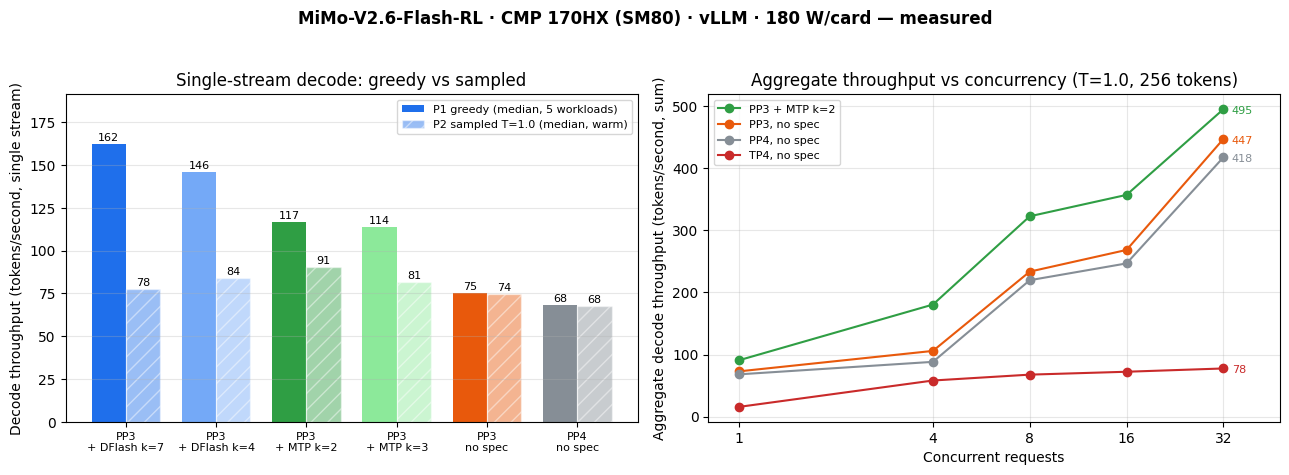

saved: assets/charts/2026-09-22-mimo-v2.6-flash-4card-pp4-vllm.{png,svg}


In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

# (a) P1 greedy vs P2 sampled, grouped per configuration
x = range(len(CONFIGS))
w = 0.38
p1 = [SS[t]['p1'] for t, _ in CONFIGS]
p2 = [SS[t]['p2'] for t, _ in CONFIGS]
b1 = ax1.bar([i - w / 2 for i in x], p1, w, color=[COLOR[t] for t, _ in CONFIGS], label='P1 greedy (median, 5 workloads)')
b2 = ax1.bar([i + w / 2 for i in x], p2, w, color=[COLOR[t] for t, _ in CONFIGS], alpha=0.45,
             hatch='//', edgecolor='white', label='P2 sampled T=1.0 (median, warm)')
for bars in (b1, b2):
    for b in bars:
        ax1.text(b.get_x() + b.get_width() / 2, b.get_height() + 2, f"{b.get_height():.0f}", ha='center', fontsize=8)
ax1.set_xticks(list(x))
ax1.set_xticklabels([l.replace(', ', chr(10)).replace(' + ', chr(10) + '+ ') for _, l in CONFIGS], fontsize=8)
ax1.set_ylabel('Decode throughput (tokens/second, single stream)')
ax1.set_title('Single-stream decode: greedy vs sampled')
ax1.set_ylim(0, max(p1) * 1.18)
ax1.grid(True, axis='y', alpha=0.3)
ax1.legend(loc='upper right', fontsize=8)

# (c) aggregate throughput vs concurrency
for topo, lv in CONC.items():
    cs = sorted(lv)
    ax2.plot(cs, [lv[c]['aggregate_tok_s'] for c in cs], marker='o', color=COLOR[topo], label=LABEL[topo])
    ax2.annotate(f"{lv[cs[-1]]['aggregate_tok_s']:.0f}", xy=(cs[-1], lv[cs[-1]]['aggregate_tok_s']),
                 xytext=(6, -3), textcoords='offset points', fontsize=8, color=COLOR[topo])
ax2.set_xscale('log', base=2)
ax2.set_xlim(0.8, 48)
ax2.set_xticks(sorted(CONC['pp3']))
ax2.set_xticklabels([str(c) for c in sorted(CONC['pp3'])])
ax2.set_xlabel('Concurrent requests')
ax2.set_ylabel('Aggregate decode throughput (tokens/second, sum)')
ax2.set_title('Aggregate throughput vs concurrency (T=1.0, 256 tokens)')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left', fontsize=8)

fig.suptitle('MiMo-V2.6-Flash-RL · CMP 170HX (SM80) · vLLM · 180 W/card — measured', fontsize=12, weight='bold')
fig.tight_layout(rect=(0, 0, 1, 0.95))
os.makedirs('../assets/charts', exist_ok=True)
fig.savefig("../assets/charts/2026-09-22-mimo-v2.6-flash-4card-pp4-vllm.png", dpi=150, bbox_inches="tight")
fig.savefig("../assets/charts/2026-09-22-mimo-v2.6-flash-4card-pp4-vllm.svg", bbox_inches="tight")
_svg = '../assets/charts/2026-09-22-mimo-v2.6-flash-4card-pp4-vllm.svg'  # strip matplotlib's trailing spaces so git diff --check stays clean
with open(_svg) as fh:
    _body = fh.read()
with open(_svg, 'w') as fh:
    fh.write(chr(10).join(line.rstrip() for line in _body.splitlines()) + chr(10))
plt.show()
print("saved: assets/charts/2026-09-22-mimo-v2.6-flash-4card-pp4-vllm.{png,svg}")

### 2.2 Decode by workload

Speculative decoding gains depend on how predictable the text is. DFlash k=7 is
strongest on counting, math and code; on prose it falls back to the no-spec rate while
MTP k=2 still gains.

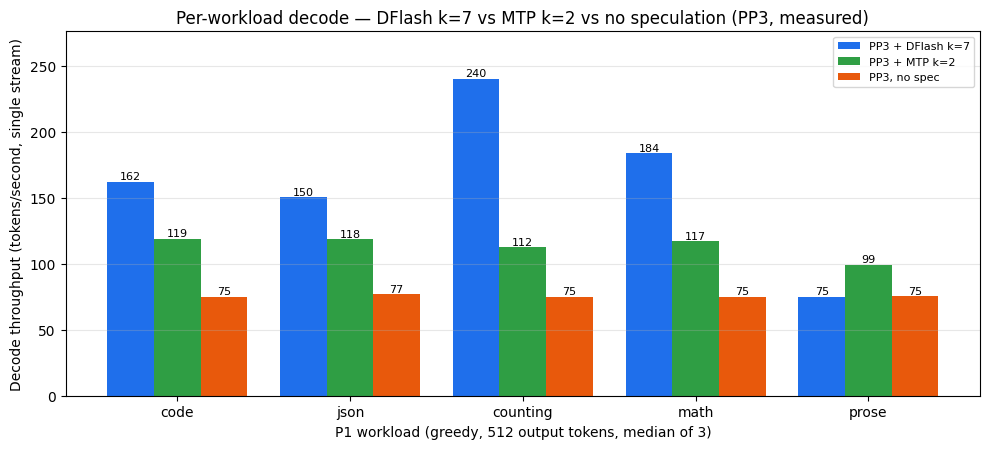

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.6))
series = ('pp3-dflash7', 'pp3-mtp2', 'pp3')
w = 0.27
for j, topo in enumerate(series):
    vals = [SS[topo]['per'][wl] for wl in WORKLOADS]
    bars = ax.bar([i + (j - 1) * w for i in range(len(WORKLOADS))], vals, w, color=COLOR[topo], label=LABEL[topo])
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 2, f"{v:.0f}", ha='center', fontsize=8)
ax.set_xticks(range(len(WORKLOADS)))
ax.set_xticklabels(WORKLOADS)
ax.set_xlabel('P1 workload (greedy, 512 output tokens, median of 3)')
ax.set_ylabel('Decode throughput (tokens/second, single stream)')
ax.set_title('Per-workload decode — DFlash k=7 vs MTP k=2 vs no speculation (PP3, measured)')
ax.set_ylim(0, max(SS['pp3-dflash7']['per'].values()) * 1.15)
ax.grid(True, axis='y', alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

In [8]:
rows = []
for topo in ('pp3-mtp2', 'pp3', 'pp4'):
    for g in receipt('bench', topo, 'gate.json'):
        rows.append([topo.upper(), g['prompt'][:44], g['answers'][0][:48].replace('|', '/'), g['correct'], g['identical']])
render_table(['Topology', 'Prompt', 'Answer (rep 1)', 'Correct 3/3', 'Identical 3/3'], rows)

| Topology | Prompt | Answer (rep 1) | Correct 3/3 | Identical 3/3 |
|---|---|---|---|---|
| PP3-MTP2 | What is the capital of Japan? One word. | Tokyo | True | True |
| PP3-MTP2 | What is 17*23? Answer with just the number. | 391 | True | True |
| PP3-MTP2 | Name the chemical symbol for gold. | The chemical symbol for gold is **Au**, derived  | True | True |
| PP3-MTP2 | Translate 'thank you' to French. | "Thank you" in French is **"merci"**. | True | True |
| PP3 | What is the capital of Japan? One word. | Tokyo | True | True |
| PP3 | What is 17*23? Answer with just the number. | 391 | True | True |
| PP3 | Name the chemical symbol for gold. | The chemical symbol for gold is **Au**, derived  | True | True |
| PP3 | Translate 'thank you' to French. | "Thank you" in French is **"merci"**. | True | True |
| PP4 | What is the capital of Japan? One word. | Tokyo | True | True |
| PP4 | What is 17*23? Answer with just the number. | 391 | True | True |
| PP4 | Name the chemical symbol for gold. | The chemical symbol for gold is **Au**, derived  | True | True |
| PP4 | Translate 'thank you' to French. | "Thank you" in French is **"merci"**. | True | False |

Greedy repeats are not bit-identical on this stack in general (the GLM lane measured
the same drift): Marlin MoE uses atomic-add reductions and the Triton DiffKV
split-softmax path changes accumulation order. Every answer above is correct; the one
PP4 non-identical case differs in wording only.

**Untested:** sustained stability run, prefill beyond 21.5k prompt tokens, and
concurrency sweeps for the DFlash configurations. These are the next measurements.

## 3. Why this model is hard on SM80

MiMo-V2.6-Flash was released for Hopper/Blackwell-class servers running TP4. This rig
is the opposite on every axis: Ampere-generation compute (SM80), 64 GiB per card,
and a PCIe Gen1 fabric with no peer-to-peer. Six separate problems stood between the
checkpoint and a correct token; they are listed in the order they were hit. Attempt
IDs (A1-A16) refer to `receipts/runtime_attempts.json`, printed at the end of section 4.

### 3.1 Every production kernel is SM90+ (A1-A5)

| Model feature | Production kernel | SM80 path used here | Receipt |
|---|---|---|---|
| Attention sinks on SWA layers | FlashAttention 3 (SM90+) | Triton DiffKV backend (implements sinks) | A1, A2 |
| DiffKV heads (QK 192 / V 128) | FA-DiffKV (SM90+), pinned in model code | Triton DiffKV; head 192 padded to 256; bf16 KV only | A2 |
| MXFP4 routed experts | TRT-LLM / CUTLASS / DeepGEMM (SM90/100) | Marlin W4A16 dequant, experts repacked at load | A4, A5 |
| FP8 block dense + attention | FP8 tensor cores (SM89+) | Marlin weight-only FP8 (W8A16) | pins |

The official vLLM image stops before weight load: the sinks assertion fires inside the
FA3 path, and because `mimo_v2.py` hard-pins the DiffKV backend, no
`VLLM_ATTENTION_BACKEND` override escapes it (A1, A2). SGLang loads further but its
Triton fused-MoE path reads packed mxfp4 experts as fp8 and faults (A4, A5). The
club fork image selects the Triton DiffKV and Marlin paths automatically.

### 3.2 The checkpoint is pre-sharded for TP4; PP forces a TP1 re-shard (A11, A12)

Fused `qkv_proj` is stored as four TP4 chunks, each with its own fp8 block scales.
Pipeline parallel runs every stage at TP1, so the loader has to dequantize, reorder and
requantize — a path almost nobody else exercises. Our first local patch sliced the
scales wrongly and the model booted into fluent-looking garbage (`2,,,,,`, A11).
Upstream vLLM #57508 fixed exactly this; the backport is fix 2 (A12).

### 3.3 The fabric rules out tensor parallel (A12, A13, A16)

No P2P, Gen1 links, and one card on an x1 riser. TP4 all-reduces every layer over that
fabric: measured **4.6x slower single-stream than PP3, and aggregate never passes ~78
tok/s** (58-78 tok/s from c=4 to c=32; cell below). PP4 is slower than PP3 at every concurrency because
the fourth stage adds a hop across the x1 card.

In [9]:
# --- Fabric check, from receipts/conc ---
tp4, pp3, pp4 = CONC['tp4'], CONC['pp3'], CONC['pp4']
print(f"c=1  PP3 {pp3[1]['aggregate_tok_s']:.1f} vs TP4 {tp4[1]['aggregate_tok_s']:.1f} tok/s -> TP4 is {pp3[1]['aggregate_tok_s'] / tp4[1]['aggregate_tok_s']:.1f}x slower")
print('TP4 aggregate c=4..32:', ', '.join(f"{tp4[c]['aggregate_tok_s']:.1f}" for c in sorted(tp4) if c >= 4), 'tok/s')
print('PP4 / PP3 aggregate  :', ', '.join(f"c={c} {pp4[c]['aggregate_tok_s'] / pp3[c]['aggregate_tok_s']:.2f}" for c in sorted(pp3)))

c=1  PP3 72.9 vs TP4 15.7 tok/s -> TP4 is 4.6x slower
TP4 aggregate c=4..32: 58.1, 67.6, 72.2, 77.5 tok/s
PP4 / PP3 aggregate  : c=1 0.93, c=4 0.83, c=8 0.94, c=16 0.92, c=32 0.93


### 3.4 161 GiB of weights on 64 GiB cards (A3, A13, A15)

Three cards hold 192 GiB, so PP3 leaves little room for KV cache and load transients.
SGLang's loader OOMed at PP3 (A3). vLLM fits with `--gpu-memory-utilization 0.97` and
an uneven layer partition: the default 16/16/16 split left the last stage (which also
holds `lm_head`) with no KV memory, so 17/16/15 moves layers forward (A13). With the
2.7 GiB DFlash drafter on the last stage the partition becomes 17/17/14 (A15), and the
drafter's memory shrinks the KV pool to roughly 22.5k tokens of context (vLLM startup
log), against 73,202 tokens without a drafter.

### 3.5 The crash that looked like a kernel bug (A6-A10)

Every full boot died with an illegal memory access inside the Marlin mxfp4 expert
repack, at a different expert each time, while the same op passed in every standalone
repro (A6-A9). GPU debugging is disabled on this card, so compute-sanitizer was not
available. The cause was the memory-unlock driver: it handed firmware-protected VRAM
(the GSP write-protected region, WPR) to the allocator, and only near-full cards ever
touched it — Xid 31 MMU REGION_VIOLATION (A10). It took 8 VM reboots to reach the root
cause; the fix is fix 1.

### 3.6 Speculative decoding under pipeline parallel (A14, A15)

- **MTP:** vLLM's default model runner creates the drafter only on the last PP rank but
  touches it on every rank (`AttributeError: drafter`); with guards added the verify
  step still produced garbage. The V2 model runner (`VLLM_USE_V2_MODEL_RUNNER=1`) works
  with no runner patch (A14).
- **DFlash:** the drafter reads hidden states tapped after layers 0/11/23/35/47, which
  live on every PP stage, while the drafter runs on the last one. Each stage now relays
  its taps forward in the intermediate tensors (the aux-hidden relay, A15).
- **vLLM caps scheduled tokens** at 2048 per step whenever speculative decoding is on
  (`max_num_scheduled_tokens is set to 2048 based on the speculative decoding settings`),
  which bounds prefill chunk size (section 4c).

### 3.7 Summary

| Challenge | Symptom | Root cause | Fix / workaround | Receipt |
|---|---|---|---|---|
| SM90-only kernels | official image asserts before load; SGLang faults in MoE | FA3 sinks, FA-DiffKV, mxfp4 TRT-LLM/CUTLASS/DeepGEMM, fp8 tensor cores | fork image: Triton DiffKV + Marlin W4A16/W8A16 | A1-A5 |
| TP4-sharded checkpoint | boots, fluent garbage | fp8 QKV scales mis-sliced in TP1 re-shard | upstream vLLM #57508 backport | A11, A12 |
| PCIe fabric | TP4 4.6x slower, aggregate tops out ~78 tok/s; PP4 < PP3 | no P2P, Gen1 links, x1 riser | PP3 on the three wide-link cards | A12, A13, A16 |
| Memory | OOM at load; last stage with no KV | 161 GiB weights on 3x64 GiB | 0.97 utilization, 17/16/15 (17/17/14 with DFlash) | A3, A13, A15 |
| Random repack crash | illegal memory access, position varies | unlock driver exposed GSP WPR to the allocator (Xid 31) | driver patch, 141 MB/card | A6-A10 |
| Spec decode under PP | missing drafter, garbage verify; DFlash taps on other stages | default runner assumes drafter on all ranks; rank-local tap index | V2 model runner; aux-hidden relay | A14, A15 |

## 4. The three fixes

### Fix 1 — memory-unlock driver handed out firmware-protected VRAM (every earlier crash)

The 64 GiB unlock (cmpunlocker `late-pma.patch`) registers the top reserved
framebuffer region `0xff7300000-0xfffffffff` (141 MB) with the physical memory
allocator. After the unlock relocates it, the GSP firmware's write-protected region
(WPR) sits inside that range (`wprStart=0xff7400000 wprEnd=0xffff00000`, logged at
boot). Any allocation that lands there faults with **Xid 31 MMU REGION_VIOLATION**,
and the driver's own memory scrubber then faults on the same pages and wedges the
GPUs until a reboot.

Only near-full cards touch that range, which is why the fault looked random, why
small standalone repros always passed, and why it showed up inside the Marlin expert
repack (the largest allocation burst of the boot). Receipt: attempts A6-A9, A10.

Fix: skip registering that region (`patches/cmpunlocker-late-pma-wprfix.diff`,
costs 141 MB per card). After the fix all four cards filled 63.0 GiB and verified every
chunk with zero Xid, and every MiMo boot since has passed the repack.

### Fix 2 — fp8 QKV re-sharding: backport the upstream vLLM fix

The checkpoint stores fused `qkv_proj` as 4 chunks of `[Q|K|V]` with per-chunk fp8
block scales (layer 0: weight `[13568,4096]`, scale `[108,32]` = 4 x 27). Under
PP the model runs at TP1, and the fork's `mimo_v2.py` must dequantize, reorder and
requantize. Our first local patch sliced scales as if they tiled the whole tensor,
corrupting every attention layer: fluent-looking garbage (`2,,,,,,`). Upstream
vLLM fixed exactly this in #57508 (`ckpt_tp = num_key_value_heads`, per-chunk scale
tiling); #57784 moves the MoE router to fp32 logits. Both apply cleanly to the
image's file: `patches/mimo_v2.py`. It is the only runtime patch for the no-spec
configurations.

### Fix 3 — the benchmark tool must count reasoning tokens

MiMo streams its thinking as `reasoning_content`. The first version of
`tools/bench_mimo.py` started TTFT at the first *content* token, so on reasoning-heavy
prompts decode time shrank and rates read as 180-350 tok/s. It now times from the first
token of either kind; all numbers above use the fixed tool.

### MTP under pipeline parallel

The V2 model runner handles MTP under PP with no runner patch (section 3.6). The MTP
file needs the same upstream QKV-sharding backport as the main model
(`patches/mimo_v2_mtp.py`, #57508). k=2 beats k=3: draft position 3 is accepted ~8%.

### DFlash under pipeline parallel

The checkpoint's `dflash/` drafter (5 SWA layers, block 8) reads target hidden states
after layers 0/11/23/35/47, spread over every PP stage. Three changes make it run:

1. `patches/mimo_v2_omni.py`: upstream #57784 adds `SupportsEagle3` to the omni wrapper
   the checkpoint resolves to (`MiMoV2OmniForCausalLM`).
2. `patches/qwen3_dflash.py`: upstream #57784 applies the drafter's
   `attention_value_scale` (0.612).
3. `patches/mimo_v2.py` (this lane): an aux-hidden relay. Each PP stage ships
   `aux_hidden_{k}` slots in its intermediate tensors and fills the taps it owns,
   indexed by *global* layer count (upstream used the rank-local index, wrong under
   PP). Same pattern as the GLM lane's DFlash2 relay. No-op when no drafter is set.

The drafter (2.7 GiB) sits on the last stage, so the partition moves to 17/17/14.
DFlash wins greedy and structured output; MTP k=2 wins at the vendor-recommended
T=1.0 and on prose.

### Speculative acceptance per draft position (measured)

From the vLLM `SpecDecoding metrics` log lines of the single-stream bench runs
(`receipts/acceptance.json`; MTP values are rounded as logged). Expected tokens per
verify step is derived as 1 + the sum of per-position acceptance.

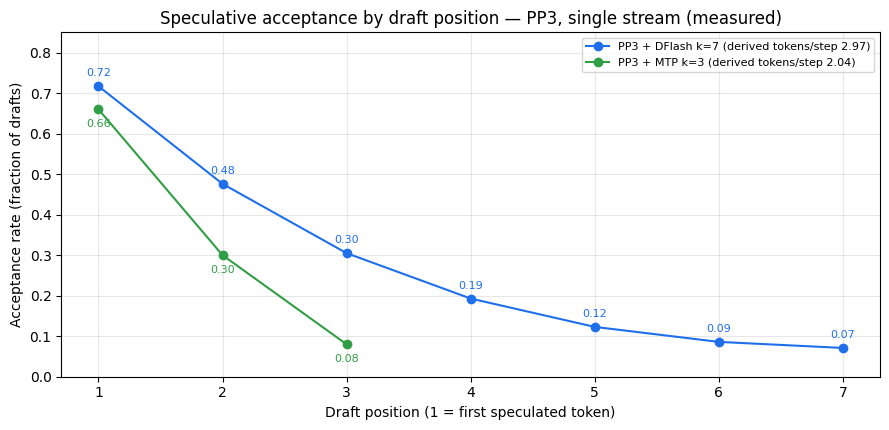

source: vLLM SpecDecoding metrics log lines, 2026-09-24, single-stream bench runs


In [10]:
acc = receipt('acceptance.json')
fig, ax = plt.subplots(figsize=(9, 4.4))
for key, topo, dy in (('dflash_k7', 'pp3-dflash7', 7), ('mtp_k3', 'pp3-mtp2', -13)):
    rates = acc[key]['per_position_acceptance']
    pos = list(range(1, len(rates) + 1))
    mean_len = 1 + sum(rates)
    ax.plot(pos, rates, marker='o', color=COLOR[topo],
            label=f"{acc[key]['label']} (derived tokens/step {mean_len:.2f})")
    for p, r in zip(pos, rates):
        ax.annotate(f"{r:.2f}", xy=(p, r), xytext=(0, dy), textcoords='offset points', ha='center', fontsize=8, color=COLOR[topo])
ax.set_xlabel('Draft position (1 = first speculated token)')
ax.set_ylabel('Acceptance rate (fraction of drafts)')
ax.set_title('Speculative acceptance by draft position — PP3, single stream (measured)')
ax.set_xticks(range(1, 8))
ax.set_ylim(0, 0.85)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
print('source:', acc['source'])

## 4b. Aggregate throughput (measured)

`tools/conc_sweep.py`: c concurrent streams, T=1.0, `ignore_eos`, 256 output tokens,
2 rounds per level, `--max-num-seqs 32`, aggregate = completion tokens / wall time.

In [11]:
rows = []
for topo, lv in CONC.items():
    rows.append([topo.upper(), *[f"{lv[c]['aggregate_tok_s']:.1f}" for c in (1, 4, 8, 16, 32)]])
render_table(['Topology', 'c=1', 'c=4', 'c=8', 'c=16', 'c=32 (tok/s)'], rows)

| Topology | c=1 | c=4 | c=8 | c=16 | c=32 (tok/s) |
|---|---|---|---|---|---|
| PP3-MTP2 | 90.9 | 180.4 | 322.6 | 357.1 | 495.1 |
| PP3 | 72.9 | 105.8 | 233.5 | 268.4 | 447.1 |
| PP4 | 68.1 | 88.2 | 219.7 | 246.7 | 417.5 |
| TP4 | 15.7 | 58.1 | 67.6 | 72.2 | 77.5 |

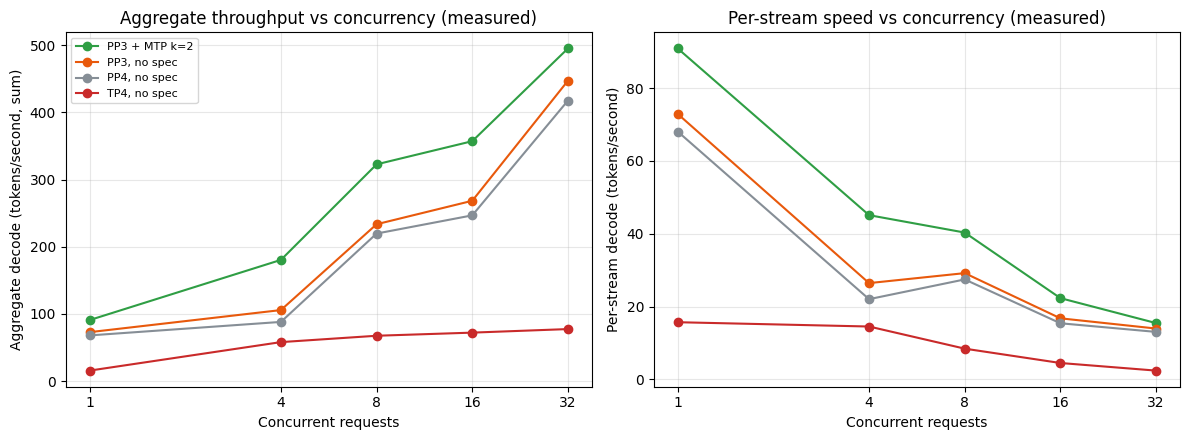

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
for topo, lv in CONC.items():
    cs = sorted(lv)
    ax1.plot(cs, [lv[c]['aggregate_tok_s'] for c in cs], marker='o', color=COLOR[topo], label=LABEL[topo])
    ax2.plot(cs, [lv[c]['per_stream_tok_s'] for c in cs], marker='o', color=COLOR[topo], label=LABEL[topo])
for ax, ylabel, title in ((ax1, 'Aggregate decode (tokens/second, sum)', 'Aggregate throughput'),
                          (ax2, 'Per-stream decode (tokens/second)', 'Per-stream speed')):
    ax.set_xscale('log', base=2)
    ax.set_xticks(sorted(CONC['pp3']))
    ax.set_xticklabels([str(c) for c in sorted(CONC['pp3'])])
    ax.set_xlabel('Concurrent requests')
    ax.set_ylabel(ylabel)
    ax.set_title(title + ' vs concurrency (measured)')
    ax.grid(True, alpha=0.3)
ax1.legend(fontsize=8)
fig.tight_layout()
plt.show()

PP3+MTP2 leads at every concurrency. PP4 trails PP3 everywhere: the fourth stage adds
a hop across the x1 card. **TP4 is 4.6x slower single-stream and tops out at ~78 tok/s
aggregate** — every layer all-reduces over Gen1 PCIe with no P2P.

## 4c. Prefill vs prompt length (measured)

`receipts/prefill.json`: uncached unique prompts, `max_tokens=1`, one request at a
time, on the PP3 + DFlash k=7 server, 2026-09-24. Seconds are rounded to 0.01 s;
prefill rate = prompt tokens / seconds. With speculative decoding on, vLLM caps
scheduled tokens at 2048 per step, so long prompts prefill in 2048-token chunks.
**Untested:** prefill without a drafter, and prompts beyond 21.5k tokens.

| Prompt tokens | Seconds | Prefill tok/s |
|---|---|---|
| 2695 | 1.19 | 2265 |
| 5391 | 1.74 | 3098 |
| 10795 | 3.23 | 3342 |
| 21516 | 6.31 | 3410 |

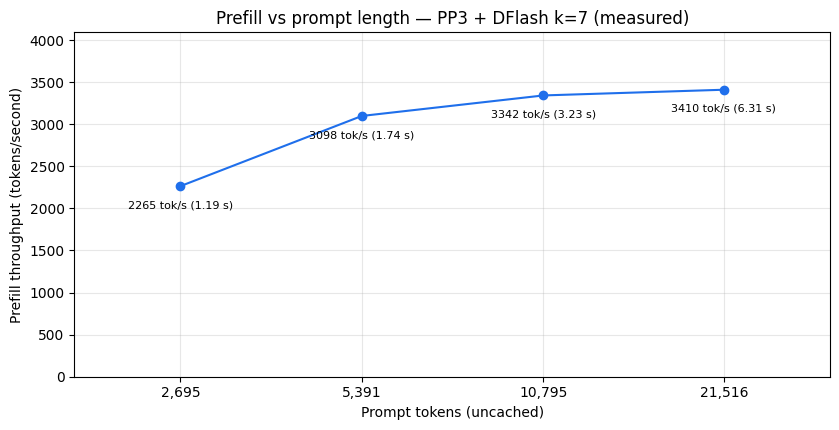

note: vLLM caps scheduled tokens to 2048 per step when speculative decoding is on (log warning: 'max_num_scheduled_tokens is set to 2048 based on the speculative decoding settings')


In [13]:
pf = receipt('prefill.json')
toks = [p['prompt_tokens'] for p in pf['points']]
secs = [p['seconds'] for p in pf['points']]
rate = [t / s for t, s in zip(toks, secs)]
render_table(['Prompt tokens', 'Seconds', 'Prefill tok/s'], [[t, s, f"{r:.0f}"] for t, s, r in zip(toks, secs, rate)])

fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.plot(toks, rate, marker='o', color=COLOR['pp3-dflash7'])
for t, s, r in zip(toks, secs, rate):
    ax.annotate(f"{r:.0f} tok/s ({s:.2f} s)", xy=(t, r), xytext=(0, -16), textcoords='offset points', ha='center', fontsize=8)
ax.set_xscale('log', base=2)
ax.set_xlim(toks[0] / 1.5, toks[-1] * 1.5)
ax.set_xticks(toks)
ax.set_xticklabels([f"{t:,}" for t in toks])
ax.set_xlabel('Prompt tokens (uncached)')
ax.set_ylabel('Prefill throughput (tokens/second)')
ax.set_title('Prefill vs prompt length — PP3 + DFlash k=7 (measured)')
ax.set_ylim(0, max(rate) * 1.2)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()
print('note:', pf['note'])

## 4d. Attempt log

Every attempt, including the failures, from `receipts/runtime_attempts.json`.

In [14]:
attempts = receipt('runtime_attempts.json')
rows = []
for a in attempts['attempts']:
    rows.append([a["id"], a.get("topology", "-")[:48], a["result"][:80]])
render_table(["Attempt", "Topology", "Result"], rows)

| Attempt | Topology | Result |
|---|---|---|
| A1-vllm-pp3-fa-backend | PP3, three >=x8 cards | FAILED at attention backend init, before weight load |
| A2-vllm-pp3-triton-backend | PP3, VLLM_ATTENTION_BACKEND=TRITON_ATTN_VLLM_V1 | FAILED identically |
| A3-sglang-pp3 | PP3, three >=x8 cards, --attention-backend trito | FAILED during weight load |
| A4-sglang-pp4 | PP4, all four cards, --attention-backend triton, | FAILED - eager mode too |
| A6-fork-pp4-marlin-repack | PP4, club fork image 487ecf187, qkv straddle fix | FAILED - illegal memory access inside gptq_marlin_repack |
| A7-to-A9-standalone-and-mitigations | standalone probes + PP4 retries (triton moe back | REPACK OP PASSES CLEAN in every isolated configuration; full-boot fault persists |
| A10-driver-wpr-root-cause | all 4 cards, full-VRAM fill | ROOT CAUSE of A6-A9: unlock driver registered the GSP WPR range with PMA; Xid 31 |
| A11-fork-pp4-boot-garbage | PP4, fork image, straddle QKV patch | BOOTS (repack passes) but output is garbage ('2,,,,,'); TP1 fp8 QKV re-shard mis |
| A12-fork-pp4-upstream-qkv-fix | PP4, all 4 cards | SERVES: gate 4/4 correct (3/4 identical), P1 68.3 tok/s, P2 67.7 tok/s |
| A13-fork-pp3-three-cards | PP3 on x8/x16/x16 cards, partition 17,16,15 | SERVES, recommended: gate 4/4 correct + identical, P1 75.0 tok/s, P2 74.4 tok/s, |
| A14-pp3-native-mtp | PP3 + MTP (mimo_mtp) k=2/k=3, V2 model runner | SERVES, fastest: k=2 P1 116.9 tok/s, P2 90.7 tok/s; k=3 P1 113.7, P2 81.4; gate  |
| A15-pp3-dflash | PP3 + shipped DFlash drafter k=7/k=4, V2 runner, | SERVES: k=7 P1 162.1 / P2 77.5 tok/s; k=4 P1 145.7 / P2 84.0; gate 4/4 |
| A16-throughput-sweep | PP3, PP3+MTP2, PP4, TP4 at c=1..32 | c=32 aggregate: PP3+MTP2 495, PP3 447, PP4 418, TP4 78 tok/s; TP4 c=1 15.7 tok/s |

## 5. Reproduce

### Driver (unlocked 170HX only)

Apply `patches/cmpunlocker-late-pma-wprfix.diff` to the cmpunlocker build tree,
rebuild the modules, reboot. Verify in the kernel log:

```bash
journalctl -k -b 0 | grep pixelml-wprfix   # one line per card
journalctl -k -b 0 | grep -c Xid            # 0
```

### Weights (NVMe strongly preferred: ~2.5 min load vs ~35 min from HDD-class NFS)

```bash
hf download XiaomiMiMo/MiMo-V2.6-Flash-RL --revision 5711b268169967567844e1e560e8a3966da959b1 --local-dir /models/mimo-v2.6-flash-rl
python3 results/2026-09-22-mimo-v2.6-flash-4card-pp4-vllm/tools/verify_checkpoint.py /models/mimo-v2.6-flash-rl
```

### Launch — PP3 on the three wide-link cards (recommended)

Pick the three cards that are not on the x1 riser (`nvidia-smi --query-gpu=index,pcie.link.width.current --format=csv`).

```bash
P=$PWD/results/2026-09-22-mimo-v2.6-flash-4card-pp4-vllm/patches
docker run -d --name mimo --gpus '"device=0,2,3"' --shm-size 32g \
  -e VLLM_PP_LAYER_PARTITION=17,16,15 \
  -v /models:/models \
  -v $P/mimo_v2.py:/usr/local/lib/python3.12/dist-packages/vllm/model_executor/models/mimo_v2.py:ro \
  -p 8000:8000 ghcr.io/pixelml/club-170hx:vllm-glm53-sm80-pp-20260905 \
  --model /models/mimo-v2.6-flash-rl --served-model-name mimo-v2.6-flash \
  --pipeline-parallel-size 3 --trust-remote-code \
  --gpu-memory-utilization 0.97 --max-model-len 16384 --max-num-seqs 16 \
  --reasoning-parser mimo
```

**Greedy/code workloads: DFlash k=7 instead.** Add `-e VLLM_USE_V2_MODEL_RUNNER=1`,
`VLLM_PP_LAYER_PARTITION=17,17,14`, mount `$P/mimo_v2_omni.py` and `$P/qwen3_dflash.py`, and use
`--speculative-config '{"method":"dflash","model":"/models/mimo-v2.6-flash-rl/dflash","num_speculative_tokens":7}'`.

**Faster: add the MTP head (k=2).** Add `-e VLLM_USE_V2_MODEL_RUNNER=1`, mount
`$P/mimo_v2_mtp.py` over `.../vllm/model_executor/models/mimo_v2_mtp.py`, and append:

```bash
  --speculative-config '{"method":"mimo_mtp","num_speculative_tokens":2}'
```

Expect `Using TRITON_ATTN_DIFFKV for attention` and `Using 'MARLIN' Mxfp4 MoE backend`
in the log. The default 16/16/16 split leaves the last rank (which also holds the
`lm_head`) with no KV memory; 17/16/15 balances it.

### Launch — PP4 on all four cards

Same command with `--gpus all`, `--pipeline-parallel-size 4`, no partition variable,
`--gpu-memory-utilization 0.85 --max-model-len 32768`. Slower here (68 tok/s): the
extra hop crosses the x1 card.

### Gate and benchmark

```bash
python3 results/2026-09-22-mimo-v2.6-flash-4card-pp4-vllm/tools/gate.py gate.json
python3 results/2026-09-22-mimo-v2.6-flash-4card-pp4-vllm/tools/bench_mimo.py --protocol p1 --out p1.json
python3 results/2026-09-22-mimo-v2.6-flash-4card-pp4-vllm/tools/bench_mimo.py --protocol p2 --out p2.json
```

### Attribution

- Model: Xiaomi MiMo team, MiMo-V2.6 release (MIT), 2026-09-22.
- MiMo QKV-sharding and router fixes: upstream vLLM #57508 and #57784.
- Memory unlock: cmpunlocker (open-source); the WPR fix is this lane's.
- PP-on-170HX shape and protocol: this club's DeepSeek-V4-Flash and GLM-5.3-Flash lanes.
- PP3 suggestion: the PR #57 thread.

## 6. Try your own prompt

Start a server from section 5, set `MIMO_ENDPOINT_URL` (for example
`http://localhost:8000`), set `LIVE = True` in the status cell, edit `PROMPT`, and run
the cell. With `LIVE = False` it prints the equivalent `curl` command and replays one
recorded gate answer from `receipts/bench/pp3-mtp2/gate.json`; no endpoint is contacted.

In [15]:
# --- Try your own prompt (editable OpenAI-compatible request) ---
import urllib.request

PROMPT = "Edit me before sending."
request = {
    "model": "mimo-v2.6-flash",
    "messages": [{"role": "user", "content": PROMPT}],
    "max_tokens": 1024,
    "temperature": 1.0, "top_p": 0.95,
}
print("curl -s $" + ENDPOINT_ENV_VAR + "/v1/chat/completions -H 'Content-Type: application/json' -d '" + json.dumps(request) + "'")

if LIVE:
    endpoint = os.environ.get(ENDPOINT_ENV_VAR)
    if not endpoint:
        raise RuntimeError(f"Set {ENDPOINT_ENV_VAR}; refusing an implicit endpoint")
    req = urllib.request.Request(endpoint.rstrip("/") + "/v1/chat/completions", data=json.dumps(request).encode(),
                                 headers={"Content-Type": "application/json"})
    with urllib.request.urlopen(req, timeout=600) as resp:
        d = json.load(resp)
    m = d["choices"][0]["message"]
    print(m.get("content"))
    usage = d.get("usage") or {}
    if usage.get("completion_tokens") is None:
        raise RuntimeError("Missing final usage.completion_tokens; refusing to report speed")
    print(usage)
else:
    g = receipt('bench', 'pp3-mtp2', 'gate.json')[0]
    print("replay (recorded gate answer, PP3 + MTP k=2):")
    print("  prompt:", g["prompt"])
    print("  answer:", g["answers"][0])
    print("To run live, set", ENDPOINT_ENV_VAR, "and LIVE = True.")

curl -s $MIMO_ENDPOINT_URL/v1/chat/completions -H 'Content-Type: application/json' -d '{"model": "mimo-v2.6-flash", "messages": [{"role": "user", "content": "Edit me before sending."}], "max_tokens": 1024, "temperature": 1.0, "top_p": 0.95}'
replay (recorded gate answer, PP3 + MTP k=2):
  prompt: What is the capital of Japan? One word.
  answer: Tokyo
To run live, set MIMO_ENDPOINT_URL and LIVE = True.
